### Analise Exploratoria de Dados : Tabela clientes.

In [2]:
import sys, os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re 



In [3]:
# Caminho do projeto (detecção dinâmica — funciona no Drive e local)
PROJECT_ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src").exists())

# adicionar ao python path
sys.path.insert(0, str(PROJECT_ROOT))
from src import db
# garantir que o working directory seja o do projeto
os.chdir(PROJECT_ROOT)

print("Working directory:", os.getcwd())

Working directory: c:\Users\carva\OneDrive\Área de Trabalho\central_eto


In [4]:
# Garantir que o src seja importável
PROJECT_ROOT = Path.cwd().resolve().parent

sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
#conferir o seu diretório de trabalho atual
os.getcwd()

'c:\\Users\\carva\\OneDrive\\Área de Trabalho\\central_eto'

In [6]:
sys.executable

'c:\\Users\\carva\\central_eto\\.venv\\Scripts\\python.exe'

In [7]:
sys.path.append("..")

# ler arquivo
sql_text = Path("queries/profiling_clientes.sql").read_text()

# separar queries pelo marcador
queries = re.split(r"-- QUERIE:", sql_text)[1:]
# executar
results = {}

for q in queries:
    name, sql = q.strip().split("\n", 1)
    results[name.strip()] = db.get_data(sql)

# ver nomes disponíveis
print(results.keys())

c:\Users\carva\OneDrive\Área de Trabalho\central_eto\src\db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, cn, params=params)


dict_keys(['DISTRIBUICAO DE CLIENTES', 'DISTRIBUICAO DE INADIMPLENCIA POR STATUS', 'PERFIL GEOGRAFICO DOS CLIENTES', 'PRIMEIRA COMPRA'])


---
## Seção 1 — Busca no Banco

Todas as consultas SQL ficam aqui: profiling, cadastro de clientes e primeira compra.
O restante do notebook opera apenas em memória.

In [8]:
sql = Path("queries/base_clientes.sql").read_text()
# remove o marcador de nome da query
sql = sql.replace("-- QUERY: base_clientes", "").strip()

df_base_clientes = db.get_data(sql)
print(df_base_clientes.shape)
df_base_clientes.head(3)

(1157, 10)


,CODIGO,NOME,CLASSE,CIDADEENTREGA,UFENTREGA,ATIVIDADE,STATUS,CODCONDICAOPAGAMENTO,CONDICAOPAGAMENTO,DIASINADIMPLENTE
0,410,MELLO & BACH DIAGNOSTICO MEDICO LTDA ...,SEM CONTRATO PRIVADO,Porto Velho,RO,CLINICA,Inativo,1.0,14 DIAS,0
1,522,SALVARE SERVICOS MEDICOS LTDA ...,INATIVO COM DEBITO,Manaus,AM,NaN,Inativo,NaN,NaN,0
2,1199,EYE CENTER SERVICOS MEDICOS LTDA ...,COM CONTRATO PRIVADO,Manaus,AM,CLINICA,Inativo,1.0,14 DIAS,30


---
## Seção 2 — Construção do DataFrame Analítico

Filtramos o cadastro para clientes com pedido desde 2023
e enriquecemos com todas as features em uma única etapa:
- `cliente_fidelidade` (parquet) → recência, RED_FLAG, intervalo
- `primeira_compra` (results SQL)
- `totais_cliente` — agregado do `cliente_mes` em memória

In [9]:
cliente_mes        = pd.read_parquet("data/processed/cliente_mes.parquet")
cliente_fidelidade = pd.read_parquet("data/processed/cliente_fidelidade.parquet")

# Totais por cliente em memória (sem ir ao banco)
totais_cliente = (
    cliente_mes
    .groupby("CLIENTE")
    .agg(total_pedidos=("total_pedidos", "sum"), total_valor=("total_valor", "sum"))
    .reset_index()
    .rename(columns={"CLIENTE": "CODIGO"})
)

fidelidade = (
    cliente_fidelidade[[
        "CLIENTE", "ultimo_pedido", "meses_sumido", "RED_FLAG",
        "total_meses_ativos", "intervalo_medio", "n_intervalos",
        "categoria_cliente", "historico_confiavel", "threshold_churn",
        "valor_ultimo_mes", "ticket_medio_ultimo_mes",
        "total_valor_historico", "ticket_medio_geral",
    ]]
    .rename(columns={"CLIENTE": "CODIGO"})
)

clientes_com_pedido = cliente_mes[["CLIENTE"]].drop_duplicates().rename(columns={"CLIENTE": "CODIGO"})

# Um único bloco de merges — todas as features por cliente
df_base_clientes_merged = (
    df_base_clientes
    .merge(clientes_com_pedido,          on="CODIGO", how="inner")  # filtra 2023
    .merge(fidelidade,                   on="CODIGO", how="left")   # recência/fidelidade
    .merge(results["PRIMEIRA COMPRA"],   on="CODIGO", how="left")   # primeira compra
    .merge(totais_cliente,               on="CODIGO", how="left")   # totais de pedidos
)

print(f"Clientes cadastrados  : {len(df_base_clientes)}")
print(f"Clientes analisados   : {len(df_base_clientes_merged)}  (com pedido desde 2023)")
print(f"Shape final           : {df_base_clientes_merged.shape}")
df_base_clientes_merged.tail(2)

Clientes cadastrados  : 1157
Clientes analisados   : 774  (com pedido desde 2023)
Shape final           : (774, 26)


,CODIGO,NOME,CLASSE,CIDADEENTREGA,UFENTREGA,ATIVIDADE,STATUS,CODCONDICAOPAGAMENTO,CONDICAOPAGAMENTO,DIASINADIMPLENTE,...,categoria_cliente,historico_confiavel,threshold_churn,valor_ultimo_mes,ticket_medio_ultimo_mes,total_valor_historico,ticket_medio_geral,primeira_compra,total_pedidos,total_valor
772,1233,PATRICIA SHIZUE KITAYAMA ...,COM CONTRATO PRIVADO,São Paulo,SP,CLINICA,Inativo,1.0,14 DIAS,0,...,baixo,False,6,216.05,216.05,216.05,216.05,2024-06-17,1,216.05
773,1435,MED MAIS SOLUCOES EM SERVICOS ESPECIAIS LTDA ...,COM CONTRATO PRIVADO,Brasília,DF,NaN,Inativo,6.0,7 DIAS,0,...,alto,False,2,14.63,14.63,401.72,24.91,2025-04-04,12,401.72


In [10]:
df_base_clientes_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CODIGO                   774 non-null    int64         
 1   NOME                     774 non-null    str           
 2   CLASSE                   774 non-null    str           
 3   CIDADEENTREGA            774 non-null    str           
 4   UFENTREGA                774 non-null    str           
 5   ATIVIDADE                732 non-null    str           
 6   STATUS                   774 non-null    str           
 7   CODCONDICAOPAGAMENTO     774 non-null    float64       
 8   CONDICAOPAGAMENTO        774 non-null    str           
 9   DIASINADIMPLENTE         774 non-null    int64         
 10  ultimo_pedido            774 non-null    datetime64[us]
 11  meses_sumido             774 non-null    int32         
 12  RED_FLAG                 774 non-null    bool  

In [11]:
from src.sanity_check import sanity_check

sanity_check(
    df_base_clientes_merged,
    value_col=[
        "CODCONDICAOPAGAMENTO",   # código de pagamento
        "DIASINADIMPLENTE",       # dias de inadimplência
        "meses_sumido",           # meses sem compra
        "total_meses_ativos",     # meses com pedido desde 2023
        "n_intervalos",           # qtd de intervalos para calcular intervalo_medio
        "threshold_churn",        # threshold por categoria (2, 3 ou 6)
        "valor_ultimo_mes",       # faturamento do último mês ativo
        "total_pedidos",          # total de pedidos desde 2023
        "total_valor",            # faturamento total desde 2023
    ],
    date_col="primeira_compra",
    id_cols="CODIGO",
)

Shape: (774, 26)

Missing:
CODIGO                       0
NOME                         0
CLASSE                       0
CIDADEENTREGA                0
UFENTREGA                    0
ATIVIDADE                   42
STATUS                       0
CODCONDICAOPAGAMENTO         0
CONDICAOPAGAMENTO            0
DIASINADIMPLENTE             0
ultimo_pedido                0
meses_sumido                 0
RED_FLAG                     0
total_meses_ativos           0
intervalo_medio            142
n_intervalos                 0
categoria_cliente            0
historico_confiavel          0
threshold_churn              0
valor_ultimo_mes             0
ticket_medio_ultimo_mes      0
total_valor_historico        0
ticket_medio_geral           0
primeira_compra              0
total_pedidos                0
total_valor                  0
dtype: int64

Duplicados:
0

Negativos em ['CODCONDICAOPAGAMENTO', 'DIASINADIMPLENTE', 'meses_sumido', 'total_meses_ativos', 'n_intervalos', 'threshold_churn', 'valor_

---
## Seção 3 — EDA de Perfil × Churn

Para cada variável cadastral: primeiro distribuição univariada, depois taxa de churn por categoria.
O objetivo não é descrever o dado — é identificar quais variáveis separam clientes que saem dos que ficam.

In [12]:
# helper: taxa de RED_FLAG por categoria
def churn_por_categoria(df, col):
    temp = df[[col, "RED_FLAG"]].copy()
    temp[col] = temp[col].fillna("(sem info)")
    return (
        temp.groupby(col)
        .agg(
            n_clientes=("RED_FLAG", "count"),
            n_churn=("RED_FLAG", "sum"),
            taxa_churn=("RED_FLAG", "mean"),
        )
        .assign(taxa_churn_fmt=lambda x: x["taxa_churn"].map("{:.1%}".format))
        .sort_values("taxa_churn", ascending=False)
    )

media_geral = df_base_clientes_merged["RED_FLAG"].mean()
print(f"Taxa de RED_FLAG geral: {media_geral:.1%}")

Taxa de RED_FLAG geral: 17.4%


In [13]:
print("Valores únicos de UF:", df_base_clientes_merged["UFENTREGA"].nunique())
df_base_clientes_merged["UFENTREGA"].value_counts(dropna=False)

Valores únicos de UF:

 8


UFENTREGA
MG    757
SP      8
ES      3
TO      2
AM      1
PE      1
BA      1
DF      1
Name: count, dtype: int64

FEATURE DEGENERADA

In [14]:
print("Valores únicos de CLASSE:", df_base_clientes_merged["CLASSE"].nunique())
df_base_clientes_merged["CLASSE"].value_counts(dropna=False)


Valores únicos de CLASSE: 5


CLASSE
COM CONTRATO PRIVADO              722
SEM CONTRATO PRIVADO               33
COM CONTRATO ORGAO PUBLICO         10
COM CONTRATO                        8
INATIVO COM DEBITO                  1
Name: count, dtype: int64

SEM CONTRATO X COM CONTRATO - SEM CONTRATO CUSTO DE SAIDA E ZERO 
ORGAO PUBLICO - COMPORTAMENTO DIFERENTE 
COM CONTRATO EH O MESMO QUE COM CONTRATO PRIVADO? 

,n_clientes,n_churn,taxa_churn_fmt
CLASSE,,,
COM CONTRATO ORGAO PUBLICO,10,5,50.0%
SEM CONTRATO PRIVADO,33,9,27.3%
COM CONTRATO PRIVADO,722,120,16.6%
COM CONTRATO,8,1,12.5%
INATIVO COM DEBITO,1,0,0.0%


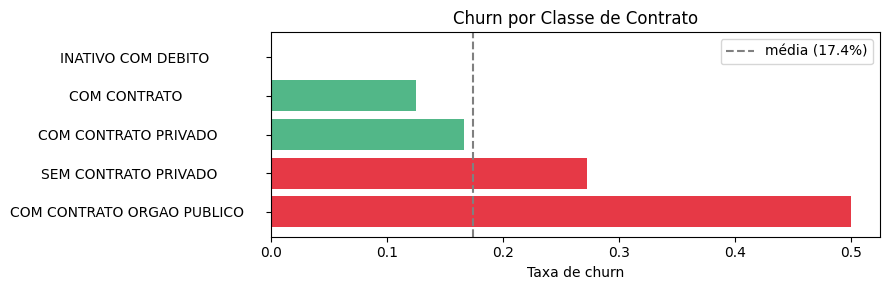

In [15]:
tab = churn_por_categoria(df_base_clientes_merged, "CLASSE")
display(tab.drop(columns="taxa_churn"))

fig, ax = plt.subplots(figsize=(9, 3))
cores = ["#e63946" if v > media_geral else "#52b788" for v in tab["taxa_churn"]]
ax.barh(tab.index, tab["taxa_churn"], color=cores)
ax.axvline(media_geral, ls="--", color="gray", label=f"média ({media_geral:.1%})")
ax.set_xlabel("Taxa de churn")
ax.set_title("Churn por Classe de Contrato")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# COM CONTRATO (8 clientes) — é o mesmo que COM CONTRATO PRIVADO?
display(
    df_base_clientes_merged[df_base_clientes_merged["CLASSE"] == "COM CONTRATO"]
    [["CODIGO", "NOME", "CLASSE", "ATIVIDADE", "STATUS"]]
)

,CODIGO,NOME,CLASSE,ATIVIDADE,STATUS


## Atividade

In [17]:
print("Valores únicos de ATIVIDADE:", df_base_clientes_merged["ATIVIDADE"].nunique())
df_base_clientes_merged["ATIVIDADE"].value_counts(dropna=False)

Valores únicos de ATIVIDADE: 4


ATIVIDADE
CLINICA                                     423
PESSOA FÍSICA                               175
HOSPITAL                                    126
NaN                                          42
INDÚSTRIA                                     8
Name: count, dtype: int64

PESSOA FISICA E O SEGMENTO MAIS INSTAVEL? 
HOSPITAL E MAIS ESTAVEL? 
INDUSTRIA E RUIDO, SO TEMOS 8 
DESCOBRIR OS NAN, O QUE SAO?


,n_clientes,n_churn,taxa_churn_fmt
ATIVIDADE,,,
HOSPITAL,126,35,27.8%
INDÚSTRIA,8,2,25.0%
CLINICA,423,73,17.3%
PESSOA FÍSICA,175,22,12.6%
(sem info),42,3,7.1%


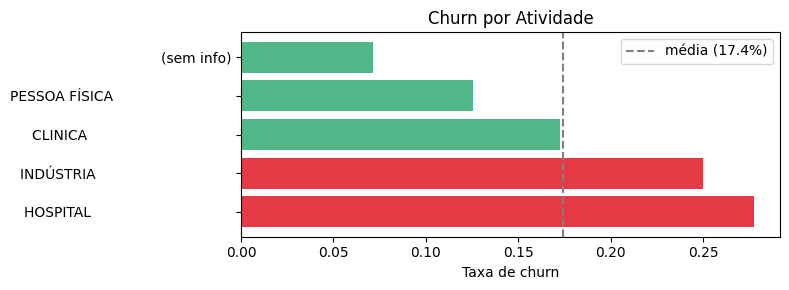

In [18]:
tab = churn_por_categoria(df_base_clientes_merged, "ATIVIDADE")
display(tab.drop(columns="taxa_churn"))

fig, ax = plt.subplots(figsize=(8, 3))
cores = ["#e63946" if v > media_geral else "#52b788" for v in tab["taxa_churn"]]
ax.barh(tab.index, tab["taxa_churn"], color=cores)
ax.axvline(media_geral, ls="--", color="gray", label=f"média ({media_geral:.1%})")
ax.set_xlabel("Taxa de churn")
ax.set_title("Churn por Atividade")
ax.legend()
plt.tight_layout()
plt.show()

## Condicao pagamento

In [19]:
print("Valores únicos de CONDICAOPAGAMENTO:", df_base_clientes_merged["CONDICAOPAGAMENTO"].nunique())
df_base_clientes_merged["CONDICAOPAGAMENTO"].value_counts(dropna=False)

Valores únicos de CONDICAOPAGAMENTO: 5


CONDICAOPAGAMENTO
7 DIAS                                 641
14 DIAS                                 87
21 DIAS                                 34
28 DIAS                                  9
30 DIAS                                  3
Name: count, dtype: int64

PRAZO E SINTOMA DE BOM RELACIONAMENTO? OU AUMENTOU O PRAZO PRO CLIENTE NAO SAIR?

DESCOMPASSO ENTRE ATRAsO E INADIMPLENCIA. *RATIO_INAD = DIASINAD / CONDICAOPAGAMENTO*


,n_clientes,n_churn,taxa_churn_fmt
CONDICAOPAGAMENTO,,,
28 DIAS,9,5,55.6%
14 DIAS,87,29,33.3%
7 DIAS,641,96,15.0%
21 DIAS,34,5,14.7%
30 DIAS,3,0,0.0%


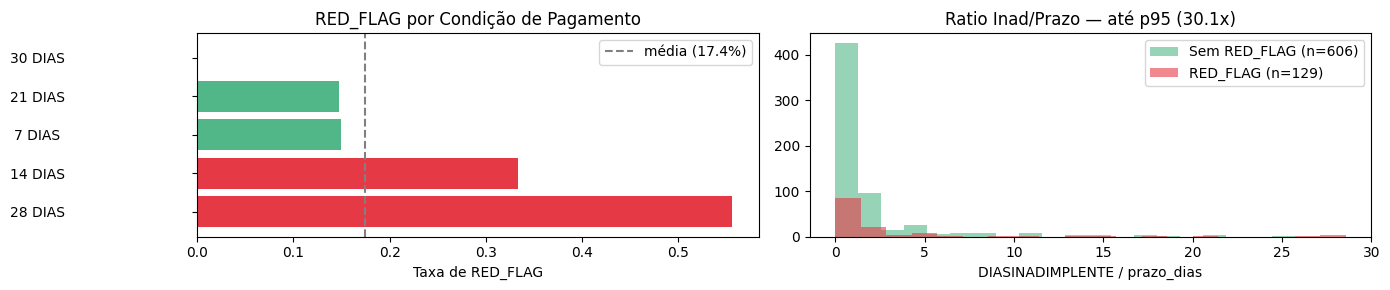

In [20]:
tab = churn_por_categoria(df_base_clientes_merged, "CONDICAOPAGAMENTO")
display(tab.drop(columns="taxa_churn"))

# ratio_inad: descompasso entre atraso e prazo (ideia da célula anterior)
df_base_clientes_merged["prazo_dias"] = (
    df_base_clientes_merged["CONDICAOPAGAMENTO"].str.extract(r"(\d+)")[0].astype(float)
)
df_base_clientes_merged["ratio_inad"] = (
    df_base_clientes_merged["DIASINADIMPLENTE"] / df_base_clientes_merged["prazo_dias"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

cores = ["#e63946" if v > media_geral else "#52b788" for v in tab["taxa_churn"]]
axes[0].barh(tab.index, tab["taxa_churn"], color=cores)
axes[0].axvline(media_geral, ls="--", color="gray", label=f"média ({media_geral:.1%})")
axes[0].set_xlabel("Taxa de RED_FLAG")
axes[0].set_title("RED_FLAG por Condição de Pagamento")
axes[0].legend()

p95_ratio = df_base_clientes_merged["ratio_inad"].quantile(0.95)
df_clip = df_base_clientes_merged[df_base_clientes_merged["ratio_inad"] <= p95_ratio]
for flag, label, color in [(False, "Sem RED_FLAG", "#52b788"), (True, "RED_FLAG", "#e63946")]:
    data = df_clip[df_clip["RED_FLAG"] == flag]["ratio_inad"]
    axes[1].hist(data, bins=20, alpha=0.6, label=f"{label} (n={len(data)})", color=color)
axes[1].set_title(f"Ratio Inad/Prazo — até p95 ({p95_ratio:.1f}x)")
axes[1].set_xlabel("DIASINADIMPLENTE / prazo_dias")
axes[1].legend()
plt.tight_layout()
plt.show()

## DIASINADIMPLENTE 

Dias de inadimplência é provavelmente a feature mais poderosa para churn. Vamos entender a distribuição e seu poder discriminativo.

=== DIASINADIMPLENTE × RED_FLAG ===
          count  mean    std  min  25%  50%   75%    max
RED_FLAG                                                
False     639.0  52.8  189.1  0.0  0.0  5.0  10.0  999.0
True      135.0  48.7  139.7  0.0  5.0  5.0  25.0  999.0

(p95 = 247 dias — clipped no histograma)


C:\Users\carva\AppData\Local\Temp\ipykernel_13328\464232064.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


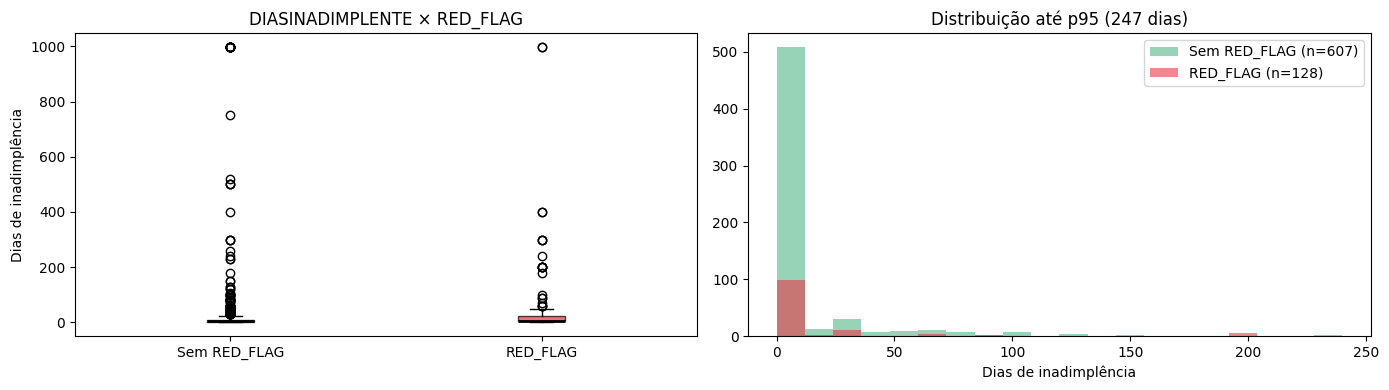

In [21]:
p95 = df_base_clientes_merged["DIASINADIMPLENTE"].quantile(0.95)

print("=== DIASINADIMPLENTE × RED_FLAG ===")
print(df_base_clientes_merged.groupby("RED_FLAG")["DIASINADIMPLENTE"].describe().round(1))
print(f"\n(p95 = {p95:.0f} dias — clipped no histograma)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_ok   = df_base_clientes_merged[df_base_clientes_merged["RED_FLAG"] == False]["DIASINADIMPLENTE"]
data_flag = df_base_clientes_merged[df_base_clientes_merged["RED_FLAG"] == True]["DIASINADIMPLENTE"]

bp = axes[0].boxplot(
    [data_ok, data_flag], labels=["Sem RED_FLAG", "RED_FLAG"],
    patch_artist=True, medianprops=dict(color="black", linewidth=2)
)
for patch, color in zip(bp["boxes"], ["#52b788", "#e63946"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("DIASINADIMPLENTE × RED_FLAG")
axes[0].set_ylabel("Dias de inadimplência")

df_clip = df_base_clientes_merged[df_base_clientes_merged["DIASINADIMPLENTE"] <= p95]
for flag, label, color in [(False, "Sem RED_FLAG", "#52b788"), (True, "RED_FLAG", "#e63946")]:
    data = df_clip[df_clip["RED_FLAG"] == flag]["DIASINADIMPLENTE"]
    axes[1].hist(data, bins=20, alpha=0.6, label=f"{label} (n={len(data)})", color=color)
axes[1].set_title(f"Distribuição até p95 ({p95:.0f} dias)")
axes[1].set_xlabel("Dias de inadimplência")
axes[1].legend()
plt.tight_layout()
plt.show()

## Categoria cliente

Clientes classificados por volume mensal de pedidos: **baixo / médio / alto / premium**.
Clientes de maior volume têm threshold de churn menor (compram mais frequente, então sumir por menos tempo já é sinal).

,n_clientes,n_churn,taxa_churn_fmt
categoria_cliente,,,
premium,17,5,29.4%
alto,65,19,29.2%
medio,57,11,19.3%
baixo,635,100,15.7%


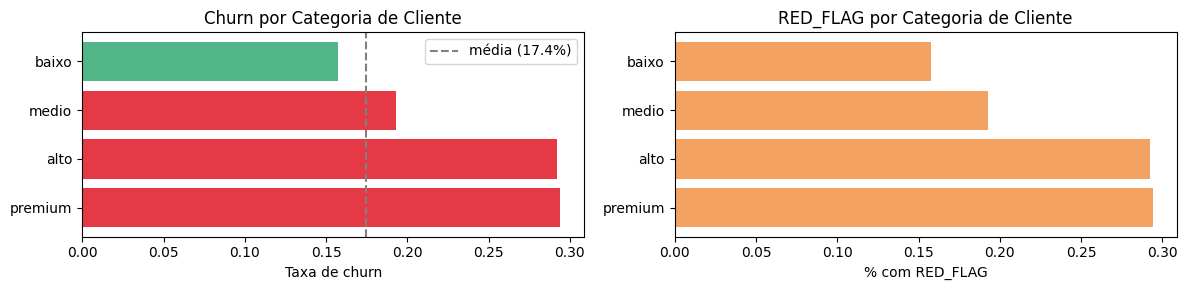

In [22]:
tab = churn_por_categoria(df_base_clientes_merged, "categoria_cliente")
display(tab.drop(columns="taxa_churn"))

ordem = ["premium", "alto", "medio", "baixo"]
tab_ord = tab.reindex([c for c in ordem if c in tab.index])
tab_rf  = (
    df_base_clientes_merged
    .groupby("categoria_cliente")["RED_FLAG"]
    .mean()
    .reindex(tab_ord.index)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

cores = ["#e63946" if v > media_geral else "#52b788" for v in tab_ord["taxa_churn"]]
axes[0].barh(tab_ord.index, tab_ord["taxa_churn"], color=cores)
axes[0].axvline(media_geral, ls="--", color="gray", label=f"média ({media_geral:.1%})")
axes[0].set_xlabel("Taxa de churn")
axes[0].set_title("Churn por Categoria de Cliente")
axes[0].legend()

axes[1].barh(tab_rf.index, tab_rf.values, color="#f4a261")
axes[1].set_xlabel("% com RED_FLAG")
axes[1].set_title("RED_FLAG por Categoria de Cliente")
plt.tight_layout()
plt.show()

=== total_valor_historico × RED_FLAG ===
          count     mean       std   min    25%     50%      75%        max
RED_FLAG                                                                   
False     639.0  27298.3  216142.4   0.0  235.8   991.6   5887.2  3811779.2
True      135.0  28760.7   96389.3  38.6  950.2  3015.5  15029.5   835701.5


C:\Users\carva\AppData\Local\Temp\ipykernel_13328\412917452.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


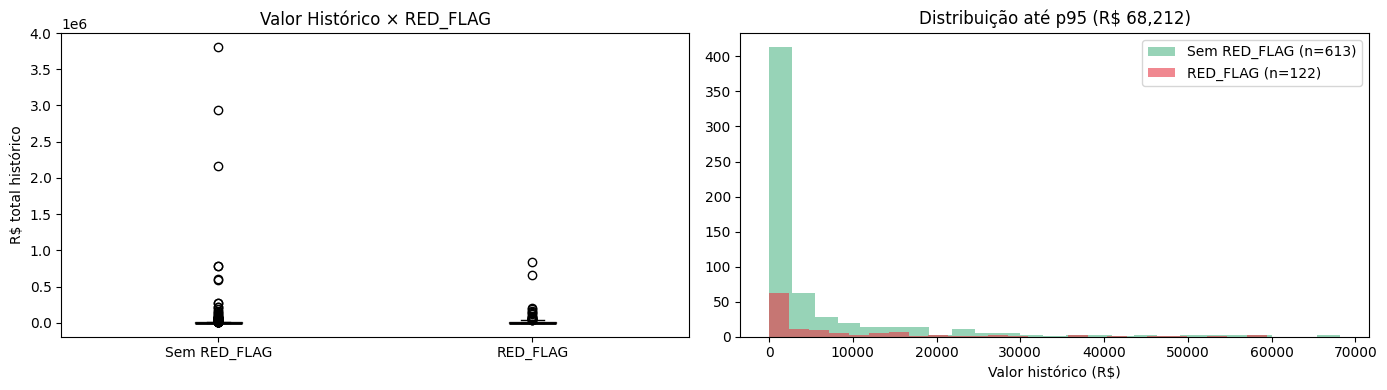

In [23]:
p95_val = df_base_clientes_merged["total_valor_historico"].quantile(0.95)

print("=== total_valor_historico × RED_FLAG ===")
print(df_base_clientes_merged.groupby("RED_FLAG")["total_valor_historico"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_ok   = df_base_clientes_merged[df_base_clientes_merged["RED_FLAG"] == False]["total_valor_historico"]
data_flag = df_base_clientes_merged[df_base_clientes_merged["RED_FLAG"] == True]["total_valor_historico"]

bp = axes[0].boxplot(
    [data_ok, data_flag], labels=["Sem RED_FLAG", "RED_FLAG"],
    patch_artist=True, medianprops=dict(color="black", linewidth=2)
)
for patch, color in zip(bp["boxes"], ["#52b788", "#e63946"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Valor Histórico × RED_FLAG")
axes[0].set_ylabel("R$ total histórico")

df_clip = df_base_clientes_merged[df_base_clientes_merged["total_valor_historico"] <= p95_val]
for flag, label, color in [(False, "Sem RED_FLAG", "#52b788"), (True, "RED_FLAG", "#e63946")]:
    data = df_clip[df_clip["RED_FLAG"] == flag]["total_valor_historico"]
    axes[1].hist(data, bins=25, alpha=0.6, label=f"{label} (n={len(data)})", color=color)
axes[1].set_title(f"Distribuição até p95 (R$ {p95_val:,.0f})")
axes[1].set_xlabel("Valor histórico (R$)")
axes[1].legend()
plt.tight_layout()
plt.show()

## Tempo de relacionamento

=== Tempo de Relacionamento × RED_FLAG ===
          count  mean   std   min   25%   50%   75%   max
RED_FLAG                                                 
False     639.0  28.0  12.9   0.0  18.0  31.0  40.0  42.0
True      135.0  36.3   7.3  13.0  34.0  40.0  41.0  42.0


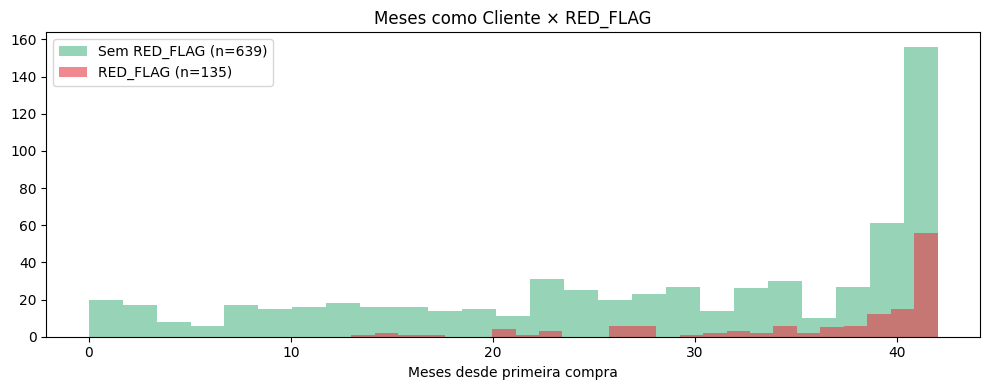

In [24]:
hoje = pd.Timestamp.today().normalize()
df_base_clientes_merged["meses_cliente"] = (
    (hoje - df_base_clientes_merged["primeira_compra"]) / pd.Timedelta(days=30)
).astype(int)

print("=== Tempo de Relacionamento × RED_FLAG ===")
print(df_base_clientes_merged.groupby("RED_FLAG")["meses_cliente"].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
for flag, label, color in [(False, "Sem RED_FLAG", "#52b788"), (True, "RED_FLAG", "#e63946")]:
    data = df_base_clientes_merged[df_base_clientes_merged["RED_FLAG"] == flag]["meses_cliente"]
    ax.hist(data, bins=25, alpha=0.6, label=f"{label} (n={len(data)})", color=color)
ax.set_title("Meses como Cliente × RED_FLAG")
ax.set_xlabel("Meses desde primeira compra")
ax.legend()
plt.tight_layout()
plt.show()

### STATUS do sistema vs. RED_FLAG

STATUS é preenchido manualmente e não tem data de saída do cliente.
RED_FLAG é calculado por comportamento (recência + histórico confiável).
O cruzamento abaixo mostra a divergência entre os dois — clientes que o sistema considera Ativos mas o comportamento aponta como em risco.

In [25]:
ct = pd.crosstab(
    df_base_clientes_merged["STATUS"],
    df_base_clientes_merged["RED_FLAG"].map({False: "Sem RED_FLAG", True: "RED_FLAG"}),
    margins=True, margins_name="Total"
)[["Sem RED_FLAG", "RED_FLAG", "Total"]]

pct = ct[["Sem RED_FLAG", "RED_FLAG"]].div(ct["Total"], axis=0).mul(100).round(1)

tabela = pd.DataFrame({
    "Sem RED_FLAG" : ct["Sem RED_FLAG"].astype(str) + "  (" + pct["Sem RED_FLAG"].astype(str) + "%)",
    "RED_FLAG"     : ct["RED_FLAG"].astype(str)     + "  (" + pct["RED_FLAG"].astype(str)     + "%)",
    "Total"        : ct["Total"].astype(str),
}, index=ct.index)

print("=== STATUS do Sistema vs. RED_FLAG ===\n")
display(tabela)

ghost = df_base_clientes_merged[
    (df_base_clientes_merged["STATUS"] == "Ativo") &
    (df_base_clientes_merged["RED_FLAG"] == True)
]
print(f"\nAtivos no sistema COM RED_FLAG: {len(ghost)} clientes ({len(ghost)/len(df_base_clientes_merged):.1%})")
print("→ O sistema os considera OK, mas o comportamento indica risco de churn.")

=== STATUS do Sistema vs. RED_FLAG ===



,Sem RED_FLAG,RED_FLAG,Total
STATUS,,,
Ativo,511 (90.1%),56 (9.9%),567
Inativo,128 (61.8%),79 (38.2%),207
Total,639 (82.6%),135 (17.4%),774



Ativos no sistema COM RED_FLAG: 56 clientes (7.2%)
→ O sistema os considera OK, mas o comportamento indica risco de churn.


In [26]:
clientes_risco = df_base_clientes_merged[df_base_clientes_merged["RED_FLAG"] == True].copy()

clientes_risco[[
    "CODIGO", "NOME", "STATUS", "ATIVIDADE", "categoria_cliente",
    "meses_sumido", "threshold_churn",
    "total_valor_historico", "DIASINADIMPLENTE",
]].sort_values("meses_sumido", ascending=False).reset_index(drop=True).to_excel(
    "data/processed/clientes_alerta.xlsx", index=False
)
print("\nSalvo em data/processed/clientes_alerta.xlsx")




Salvo em data/processed/clientes_alerta.xlsx


In [27]:
tabela = clientes_risco[[
    "CODIGO", "NOME", "STATUS", "ATIVIDADE", "categoria_cliente",
    "meses_sumido", "threshold_churn",
    "total_valor_historico", "DIASINADIMPLENTE",
]].sort_values("meses_sumido", ascending=False).reset_index(drop=True)

display(tabela)
tabela.to_excel("data/processed/clientes_alerta.xlsx", index=False)


,CODIGO,NOME,STATUS,ATIVIDADE,categoria_cliente,meses_sumido,threshold_churn,total_valor_historico,DIASINADIMPLENTE
0,65,INSTITUTO DE CIRURG E GAST PROF JOSE G P COELH...,Inativo,HOSPITAL,alto,37,2,12899.70,30
1,7,INSTITUTO DE CIRURG E GAST PROF JOSE G P COELH...,Inativo,HOSPITAL,alto,37,2,16261.87,30
2,120,CASA DE SAUDE SANTA MARIA LTDA ...,Inativo,HOSPITAL,baixo,35,6,3891.96,60
3,24,CASA DE SAUDE E MAT. NOSSA SENHORA DE FATIMA S...,Inativo,HOSPITAL,baixo,35,6,4921.13,999
4,21,ONCOBIO SERVICOS DE SAUDE SA ...,Inativo,CLINICA,premium,34,2,80694.33,30
...,...,...,...,...,...,...,...,...,...
130,807,FUNDACAO OSWALDO CRUZ ...,Inativo,NaN,medio,5,3,58999.95,30
131,15,IRMANDADE N. S. DAS MERCES DE MONTES CLARO ...,Inativo,HOSPITAL,alto,4,2,835701.46,5
132,29,HOSPITAL METROPOLITANO ODILON BEHRENS - HOB ...,Inativo,HOSPITAL,premium,4,2,659091.66,10
133,174,N.S IMPLANTES E COMERCIO DE PRODUTOS HOSPITALA...,Ativo,CLINICA,medio,4,3,36253.89,10


---
## Seção 5 — df_master

Tabela final por cliente, pronta para modelagem.
Resultado de todos os merges feitos na Seção 2 + label de churn da Seção 4.

In [28]:
df_master = df_base_clientes_merged.rename(columns={
    "ultimo_pedido" : "ultima_compra",
    "meses_sumido"  : "meses_sem_compra",
    "STATUS"        : "status_sistema",
})

print("=== df_master ===")
print(f"Shape: {df_master.shape}")
print(f"Colunas: {list(df_master.columns)}")
print(f"\nDistribuição do target (RED_FLAG):")
print(df_master["RED_FLAG"].value_counts().rename({False: "Sem risco", True: "Em risco"}))
print(f"Taxa de RED_FLAG: {df_master['RED_FLAG'].mean():.1%}")
df_master.head(5)

=== df_master ===
Shape: (774, 29)
Colunas: ['CODIGO', 'NOME', 'CLASSE', 'CIDADEENTREGA', 'UFENTREGA', 'ATIVIDADE', 'status_sistema', 'CODCONDICAOPAGAMENTO', 'CONDICAOPAGAMENTO', 'DIASINADIMPLENTE', 'ultima_compra', 'meses_sem_compra', 'RED_FLAG', 'total_meses_ativos', 'intervalo_medio', 'n_intervalos', 'categoria_cliente', 'historico_confiavel', 'threshold_churn', 'valor_ultimo_mes', 'ticket_medio_ultimo_mes', 'total_valor_historico', 'ticket_medio_geral', 'primeira_compra', 'total_pedidos', 'total_valor', 'prazo_dias', 'ratio_inad', 'meses_cliente']

Distribuição do target (RED_FLAG):
RED_FLAG
Sem risco    639
Em risco     135
Name: count, dtype: int64
Taxa de RED_FLAG: 17.4%


,CODIGO,NOME,CLASSE,CIDADEENTREGA,UFENTREGA,ATIVIDADE,status_sistema,CODCONDICAOPAGAMENTO,CONDICAOPAGAMENTO,DIASINADIMPLENTE,...,valor_ultimo_mes,ticket_medio_ultimo_mes,total_valor_historico,ticket_medio_geral,primeira_compra,total_pedidos,total_valor,prazo_dias,ratio_inad,meses_cliente
0,1199,EYE CENTER SERVICOS MEDICOS LTDA ...,COM CONTRATO PRIVADO,Manaus,AM,CLINICA,Inativo,1.0,14 DIAS,30,...,18.10,18.100,274.77,16.136500,2024-04-01,17,274.77,14.0,2.142857,26
1,1094,LIMED SERVICOS MEDICOS LTDA ...,COM CONTRATO PRIVADO,Palmas,TO,CLINICA,Inativo,1.0,14 DIAS,0,...,1771.31,885.655,5878.67,760.071667,2023-10-30,9,5878.67,14.0,0.000000,32
2,1293,CLINICA DE GASTROENTEROLOGIA DE PALMAS LTDA ...,COM CONTRATO PRIVADO,Palmas,TO,CLINICA,Inativo,1.0,14 DIAS,0,...,150.55,150.550,331.21,165.605000,2024-08-14,2,331.21,14.0,0.000000,22
3,1330,MAIS VIDA SERVICOS DE SAUDE LTDA ...,COM CONTRATO PRIVADO,Recife,PE,CLINICA,Inativo,6.0,7 DIAS,5,...,2007.35,1003.675,12961.93,719.746690,2024-10-11,23,12961.93,7.0,0.714286,20
4,930,HELIANE DIAS MOREIRA ...,COM CONTRATO PRIVADO,Teixeira de Freitas,BA,PESSOA FÍSICA,Inativo,6.0,7 DIAS,0,...,0.00,0.000,756.00,378.000000,2023-01-30,2,756.00,7.0,0.000000,41


In [29]:
df_master.to_parquet("data/processed/df_master.parquet", index=False)
print("df_master salvo em data/processed/df_master.parquet")


df_master salvo em data/processed/df_master.parquet
